In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
train_df = pd.read_excel(r'/Users/_tharun_kc/Downloads/Data_Train.xlsx')

In [3]:
train_df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
test_df = pd.read_excel(r'/Users/_tharun_kc/Downloads/Test_set.xlsx')

In [11]:
test_df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included
3,Multiple carriers,21/05/2019,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info
4,Air Asia,24/06/2019,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info


In [6]:
df = pd.concat([train_df,test_df])

In [7]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882.0
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0
...,...,...,...,...,...,...,...,...,...,...,...
2666,Air India,6/06/2019,Kolkata,Banglore,CCU → DEL → BLR,20:30,20:25 07 Jun,23h 55m,1 stop,No info,NaN
2667,IndiGo,27/03/2019,Kolkata,Banglore,CCU → BLR,14:20,16:55,2h 35m,non-stop,No info,NaN
2668,Jet Airways,6/03/2019,Delhi,Cochin,DEL → BOM → COK,21:50,04:25 07 Mar,6h 35m,1 stop,No info,NaN
2669,Air India,6/03/2019,Delhi,Cochin,DEL → BOM → COK,04:00,19:15,15h 15m,1 stop,No info,NaN


In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 13354 entries, 0 to 2670
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  str    
 1   Date_of_Journey  13354 non-null  str    
 2   Source           13354 non-null  str    
 3   Destination      13354 non-null  str    
 4   Route            13353 non-null  str    
 5   Dep_Time         13354 non-null  str    
 6   Arrival_Time     13354 non-null  str    
 7   Duration         13354 non-null  str    
 8   Total_Stops      13353 non-null  str    
 9   Additional_Info  13354 non-null  str    
 10  Price            10683 non-null  float64
dtypes: float64(1), str(10)
memory usage: 1.2 MB


In [11]:
df.shape

(13354, 11)

In [12]:
df1 = df.copy()

In [39]:
df['Year'] = df['Date_of_Journey'].str.split('/').str[2]

KeyError: 'Date_of_Journey'

In [18]:
df['Month'] = df['Date_of_Journey'].str.split('/').str[1]

In [19]:
df['Day'] = df['Date_of_Journey'].str.split('/').str[0]

In [23]:
df.drop('Date_of_Journey',inplace = True,axis = 1)

In [30]:
df.head(10)

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Year,Month,Day
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0,2019,3,24
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0,2019,5,1
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882.0,2019,6,9
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0,2019,5,12
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0,2019,3,1
5,SpiceJet,Kolkata,Banglore,CCU → BLR,09:00,11:25,2h 25m,non-stop,No info,3873.0,2019,6,24
6,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,18:55,10:25 13 Mar,15h 30m,1 stop,In-flight meal not included,11087.0,2019,3,12
7,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,08:00,05:05 02 Mar,21h 5m,1 stop,No info,22270.0,2019,3,1
8,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,08:55,10:25 13 Mar,25h 30m,1 stop,In-flight meal not included,11087.0,2019,3,12
9,Multiple carriers,Delhi,Cochin,DEL → BOM → COK,11:25,19:15,7h 50m,1 stop,No info,8625.0,2019,5,27


In [27]:
for x in ['Year','Month','Day']:
    df[x] = df[x].astype(int)

In [37]:
df['Arrival_Time'] = df['Arrival_Time'].apply(lambda x : x.split()[0])

In [38]:
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Year,Month,Day
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,non-stop,No info,3897.0,2019,3,24
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0,2019,5,1
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,19h,2 stops,No info,13882.0,2019,6,9
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0,2019,5,12
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0,2019,3,1


In [41]:
df.isnull().sum()

Airline               0
Source                0
Destination           0
Route                 1
Dep_Time              0
Arrival_Time          0
Duration              0
Total_Stops           1
Additional_Info       0
Price              2671
Year                  0
Month                 0
Day                   0
dtype: int64

In [45]:
df['Arrival_hour'] = df['Arrival_Time'].str.split(':').str[0]


In [47]:
df1['Arrival_Time'] = df1['Arrival_Time'].apply(lambda x : x.split()[0])

In [49]:
df['Arrival_min'] = df1['Arrival_Time'].str.split(':').str[1]

In [50]:
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Year,Month,Day,Arrival_hour,Arrival_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01,2h 50m,non-stop,No info,3897.0,2019,3,24,01,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13,7h 25m,2 stops,No info,7662.0,2019,5,1,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04,19h,2 stops,No info,13882.0,2019,6,9,04,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23,5h 25m,1 stop,No info,6218.0,2019,5,12,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21,4h 45m,1 stop,No info,13302.0,2019,3,1,21,35


In [52]:
df[['Arrival_hour','Arrival_min']] = df[['Arrival_hour','Arrival_min']].apply(lambda x : x.astype(int))

In [53]:
df.info()

<class 'pandas.DataFrame'>
Index: 13354 entries, 0 to 2670
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  str    
 1   Source           13354 non-null  str    
 2   Destination      13354 non-null  str    
 3   Route            13353 non-null  str    
 4   Dep_Time         13354 non-null  str    
 5   Arrival_Time     13354 non-null  object 
 6   Duration         13354 non-null  str    
 7   Total_Stops      13353 non-null  str    
 8   Additional_Info  13354 non-null  str    
 9   Price            10683 non-null  float64
 10  Year             13354 non-null  int64  
 11  Month            13354 non-null  int64  
 12  Day              13354 non-null  int64  
 13  Arrival_hour     13354 non-null  int64  
 14  Arrival_min      13354 non-null  int64  
dtypes: float64(1), int64(5), object(1), str(8)
memory usage: 2.1+ MB


In [56]:
df.drop('Arrival_Time',axis = 1,inplace = True)

In [57]:
df.head(1)

,Airline,Source,Destination,Route,Dep_Time,Duration,Total_Stops,Additional_Info,Price,Year,Month,Day,Arrival_hour,Arrival_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,2h 50m,non-stop,No info,3897.0,2019,3,24,1,10


In [67]:
df1.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Year
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,non-stop,No info,3897.0,2019
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0,2019
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,19h,2 stops,No info,13882.0,2019
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0,2019
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0,2019


In [58]:
df['Departure_hour'] = df1['Dep_Time'].str.split(':').str[0]

In [68]:
df['Departure_min'] = df1['Dep_Time'].str.split(':').str[1]

In [69]:
df.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Year,Month,Day,Arrival_hour,Arrival_min,Departure_hour,Departure_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897.0,2019,3,24,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662.0,2019,5,1,13,15,05,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882.0,2019,6,9,4,25,09,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218.0,2019,5,12,23,30,18,05
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302.0,2019,3,1,21,35,16,50


In [71]:
df[['Departure_hour','Departure_min']] = df[['Departure_hour','Departure_min']].apply(lambda x: x.astype(int))

In [72]:
df.info()

<class 'pandas.DataFrame'>
Index: 13354 entries, 0 to 2670
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  str    
 1   Source           13354 non-null  str    
 2   Destination      13354 non-null  str    
 3   Route            13353 non-null  str    
 4   Duration         13354 non-null  str    
 5   Total_Stops      13353 non-null  str    
 6   Additional_Info  13354 non-null  str    
 7   Price            10683 non-null  float64
 8   Year             13354 non-null  int64  
 9   Month            13354 non-null  int64  
 10  Day              13354 non-null  int64  
 11  Arrival_hour     13354 non-null  int64  
 12  Arrival_min      13354 non-null  int64  
 13  Departure_hour   13354 non-null  int64  
 14  Departure_min    13354 non-null  int64  
dtypes: float64(1), int64(7), str(7)
memory usage: 2.1 MB


In [73]:
df['Total_Stops'].unique()

<StringArray>
['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops']
Length: 6, dtype: str

In [79]:
df['Total_Stops'] = df['Total_Stops'].map({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4,'NaN':2})

In [80]:
df.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Year,Month,Day,Arrival_hour,Arrival_min,Departure_hour,Departure_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,NaN,No info,3897.0,2019,3,24,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,NaN,No info,7662.0,2019,5,1,13,15,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,NaN,No info,13882.0,2019,6,9,4,25,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,NaN,No info,6218.0,2019,5,12,23,30,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,NaN,No info,13302.0,2019,3,1,21,35,16,50


In [84]:
df1[df1['Total_Stops'].isnull()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Year
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25,23h 40m,NaN,No info,7480.0,2019


In [95]:
df['Total_Stops'] = df1['Total_Stops'].map({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4})
df['Total_Stops'] = df['Total_Stops'].fillna(2).astype(int)

In [97]:
df['Total_Stops'].isnull().sum()

np.int64(0)

In [98]:
df.drop('Route',axis = 1, inplace = True)

In [99]:
df.head()

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Year,Month,Day,Arrival_hour,Arrival_min,Departure_hour,Departure_min
0,IndiGo,Banglore,New Delhi,2h 50m,0,No info,3897.0,2019,3,24,1,10,22,20
1,Air India,Kolkata,Banglore,7h 25m,2,No info,7662.0,2019,5,1,13,15,5,50
2,Jet Airways,Delhi,Cochin,19h,2,No info,13882.0,2019,6,9,4,25,9,25
3,IndiGo,Kolkata,Banglore,5h 25m,1,No info,6218.0,2019,5,12,23,30,18,5
4,IndiGo,Banglore,New Delhi,4h 45m,1,No info,13302.0,2019,3,1,21,35,16,50


In [105]:
df['Additional_Info'].unique()

<StringArray>
[                     'No info',  'In-flight meal not included',
 'No check-in baggage included',              '1 Short layover',
                      'No Info',               '1 Long layover',
              'Change airports',               'Business class',
               'Red-eye flight',               '2 Long layover']
Length: 10, dtype: str

In [128]:
def dur_minutes(x):
    x = x.strip()
    h = 0
    m = 0
    if 'h' in x:
        part = x.split('h')
        h = int(part[0])
        x = part[1]
    if 'm' in x:
        part = x.replace('m','')
        part = int(part.strip())
        m = part
    return (h * 60)+ m

In [130]:
df['Duration'] = df['Duration'].apply(dur_minutes)

In [132]:
df.info()

<class 'pandas.DataFrame'>
Index: 13354 entries, 0 to 2670
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  str    
 1   Source           13354 non-null  str    
 2   Destination      13354 non-null  str    
 3   Duration         13354 non-null  int64  
 4   Total_Stops      13354 non-null  int64  
 5   Additional_Info  13354 non-null  str    
 6   Price            10683 non-null  float64
 7   Year             13354 non-null  int64  
 8   Month            13354 non-null  int64  
 9   Day              13354 non-null  int64  
 10  Arrival_hour     13354 non-null  int64  
 11  Arrival_min      13354 non-null  int64  
 12  Departure_hour   13354 non-null  int64  
 13  Departure_min    13354 non-null  int64  
dtypes: float64(1), int64(9), str(4)
memory usage: 2.0 MB


In [133]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()

Task was destroyed but it is pending!
task: <Task pending name='Task-598' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-599' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:563]>
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/_param_validation.py:17: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  from sklearn.utils.validation import _is_arraylike_not_scalar
Task was destroyed but it is pending!
task: <Task pending name='Task-599' coro=<Kernel.shell_main() running at /Library/Frameworks/Py

In [141]:
df.drop(['Airline'],axis = 1,inplace = True)

In [142]:
df.head()

,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Year,Month,Day,Arrival_hour,...,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy
0,Banglore,New Delhi,170,0,No info,3897.0,2019,3,24,1,...,False,True,False,False,False,False,False,False,False,False
1,Kolkata,Banglore,445,2,No info,7662.0,2019,5,1,13,...,False,False,False,False,False,False,False,False,False,False
2,Delhi,Cochin,1140,2,No info,13882.0,2019,6,9,4,...,False,False,True,False,False,False,False,False,False,False
3,Kolkata,Banglore,325,1,No info,6218.0,2019,5,12,23,...,False,True,False,False,False,False,False,False,False,False
4,Banglore,New Delhi,285,1,No info,13302.0,2019,3,1,21,...,False,True,False,False,False,False,False,False,False,False


In [143]:
airline_cols = [col for col in df.columns if col.startswith('Airline_')]
df[airline_cols] = df[airline_cols].astype(int)

In [144]:
df.head()

,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Year,Month,Day,Arrival_hour,...,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy
0,Banglore,New Delhi,170,0,No info,3897.0,2019,3,24,1,...,0,1,0,0,0,0,0,0,0,0
1,Kolkata,Banglore,445,2,No info,7662.0,2019,5,1,13,...,0,0,0,0,0,0,0,0,0,0
2,Delhi,Cochin,1140,2,No info,13882.0,2019,6,9,4,...,0,0,1,0,0,0,0,0,0,0
3,Kolkata,Banglore,325,1,No info,6218.0,2019,5,12,23,...,0,1,0,0,0,0,0,0,0,0
4,Banglore,New Delhi,285,1,No info,13302.0,2019,3,1,21,...,0,1,0,0,0,0,0,0,0,0


In [145]:
df = pd.get_dummies(df, columns=['Source', 'Destination', 'Additional_Info'], drop_first=True, dtype=int)
df.head()

,Duration,Total_Stops,Price,Year,Month,Day,Arrival_hour,Arrival_min,Departure_hour,Departure_min,...,Destination_New Delhi,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No Info,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
0,170,0,3897.0,2019,3,24,1,10,22,20,...,1,0,0,0,0,0,0,0,1,0
1,445,2,7662.0,2019,5,1,13,15,5,50,...,0,0,0,0,0,0,0,0,1,0
2,1140,2,13882.0,2019,6,9,4,25,9,25,...,0,0,0,0,0,0,0,0,1,0
3,325,1,6218.0,2019,5,12,23,30,18,5,...,0,0,0,0,0,0,0,0,1,0
4,285,1,13302.0,2019,3,1,21,35,16,50,...,1,0,0,0,0,0,0,0,1,0


In [154]:
train_df = df[~df['Price'].isnull()]

In [155]:
test_df = df[df['Price'].isnull()]

In [156]:
X=train_df.drop('Price',axis=1)

In [157]:
y=train_df['Price']

In [158]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=0.33, random_state=42)

In [159]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [162]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)



In [163]:
y_pred = lr.predict(X_test)

In [164]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.6909782447091231
MAE: 1754.2781519952389
RMSE: 2475.5801837431086


In [166]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), params, cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best R2:", grid.best_score_)

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}
Best R2: 0.8533702577748796


In [169]:
# pip install xgboost first if not installed
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("XGB R2:", r2_score(y_test, y_pred_xgb))

XGB R2: 0.8968175593745371


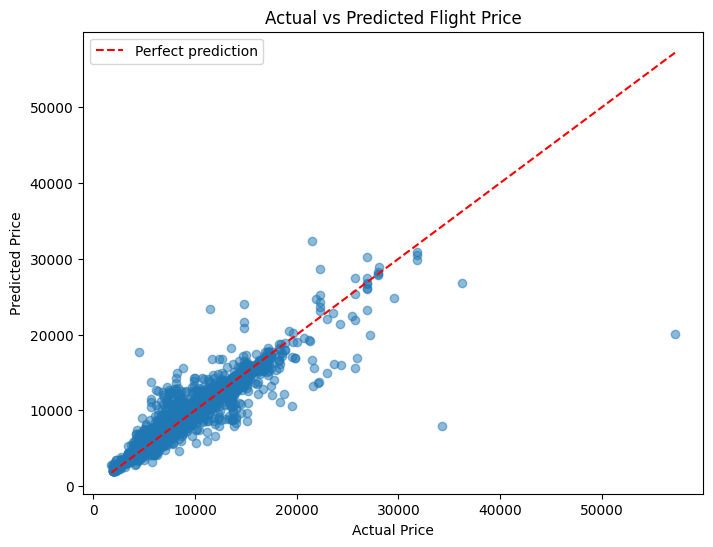

In [173]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect prediction')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Price")
plt.legend()
plt.show()

In [172]:
best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test)

In [174]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_best,
    'Difference': y_test.values - y_pred_best
})
comparison.head(20)

,Actual,Predicted,Difference
0,10844.0,10992.880000,-148.880000
1,4959.0,5486.880000,-527.880000
2,14781.0,14532.066667,248.933333
3,3858.0,3782.926667,75.073333
4,12898.0,12974.566667,-76.566667
5,10529.0,9676.858952,852.141048
6,16079.0,15900.050000,178.950000
7,7229.0,7221.103333,7.896667
8,3597.0,3600.473333,-3.473333
9,16289.0,16188.080000,100.920000


In [175]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_best,
    'Difference': y_test.values - y_pred_best
})
comparison['Abs_Error'] = comparison['Difference'].abs()
comparison.sort_values('Abs_Error', ascending=False).head(10)

,Actual,Predicted,Difference,Abs_Error
967,57209.0,20130.600000,37078.400000,37078.400000
1006,34273.0,7972.936667,26300.063333,26300.063333
733,4435.0,17699.836667,-13264.836667,13264.836667
2224,11507.0,23382.213333,-11875.213333,11875.213333
3479,21483.0,32382.996667,-10899.996667,10899.996667
373,25703.0,15610.506667,10092.493333,10092.493333
704,36235.0,26828.593333,9406.406667,9406.406667
2807,14762.0,24093.860000,-9331.860000,9331.860000
2217,25913.0,16903.012500,9009.987500,9009.987500
1984,19508.0,10561.332694,8946.667306,8946.667306


In [176]:
import numpy as np
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

best_rf.fit(X_train, y_train_log)
y_pred_log = best_rf.predict(X_test)
y_pred_actual = np.expm1(y_pred_log)  # convert back to original scale

from sklearn.metrics import r2_score
print("R2 after log transform:", r2_score(y_test, y_pred_actual))

R2 after log transform: 0.8862538097241858


In [177]:
import joblib
joblib.dump(best_rf, 'flight_price_model_log.pkl')
joblib.dump(sc, 'scaler.pkl')

['scaler.pkl']